this step is about calculatin the optical flow 
computer do not see movement . to computers video is about the pixels changing colours 

so to represent movement we use optical flow - it is a mathematical map that says the pixel at (x , y) moved 5 pixels right and  2 pixels down
why need this ?
because to geerate the intermediate framewe cannot fade frame A into frame B . we have to move the pixeks where they belong 

optical flow calculates motion vector for every pixel . 
it is a way to measure how pixels move from one frame to the next frame

each pixel gets an arrow showing a) direction of movement b)speed (how far it moves)
so for each pixel (x , y) we have a (dx , dy)  ie, horizondal movement and vertical movement

why it matters in frame interpolation ?
two frames 
-frame a (at time t-1)
-frame b (at time t+1)

optical flow tells how pixels are moved in frame a to frame b
so a) you can calculate the halfway point b) move those corresponding pixel halfway c) use this to generate the frame c at time t

without optical flow meaning - you blur all the inages together 

sparse optical flow - tracks specific pixel points 
dense optical flow - caculate motion for every pixel 


files imported 
input is taken from the dataset triplets (ie , the original coloured images)
output - folder dataset - folder - flow 

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# --- CONFIGURATION ---
INPUT_DIR = 'dataset/triplets'  # We load the original color images
OUTPUT_DIR = 'dataset/flow'     # We will save the motion data here

this optical flow is achieved through franeback's algorithm
- converts the image into greyscale 
- divide the pixels into small neighbourhood (images are noe in ptached of pixels)
- approximation if each neighbourhood (each of these patch is represented as a smooth curved surface)
- if patch is shifted right the curve is shifed right .
- from the curve the displacemnt vector is calculayted ie dx and dy

dense meaning - each pixel like this is calculated 

this is calculated in the program using "cv2.calcOpticalFlowFarneback" function 

In [2]:
def compute_optical_flow(prev, next_frame):
    """
    Calculates Dense Optical Flow using Farneback's algorithm.
    Returns: flow (h, w, 2) array. 
             channel 0 = horizontal movement (dx)
             channel 1 = vertical movement (dy)
    """
    # 1. Convert to Grayscale (Flow needs intensity, not color)
    prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)
    next_gray = cv2.cvtColor(next_frame, cv2.COLOR_BGR2GRAY)

    # 2. Calculate Flow
    # parameters: pyr_scale, levels, winsize, iterations, poly_n, poly_sigma, flags
    # These are standard "good" values for animation
    flow = cv2.calcOpticalFlowFarneback(prev_gray, next_gray, None, 
                                        0.5, 3, 15, 3, 5, 1.2, 0)
    return flow

this data from optical flow is transfered into viewable image using hsv colour wheel 
h-hue
s-saturation
v-value
colors can be represented as the value of the angle in hsv wheel

noe each pixel has (dx , dy)
each pixel also has a) angle of motion (or direction) b) magnitude (or speed)

from the angle of motion we can derive which colour from the hsv colour wheel
and the magnitude or the speed will represent the brightness of that pixel .


In [3]:
def visualize_flow(flow):
    """
    Converts flow data into a viewable image using the HSV color wheel.
    Color = Direction, Intensity = Speed.
    """
    h, w = flow.shape[:2]
    hsv = np.zeros((h, w, 3), dtype=np.uint8)
    hsv[..., 1] = 255 # Set Saturation to max

    # Convert (dx, dy) to Polar Coordinates (Magnitude, Angle)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    # Map Angle to Hue (Direction)
    hsv[..., 0] = ang * 180 / np.pi / 2
    
    # Map Magnitude to Value (Speed) - Normalize for visibility
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

    # Convert HSV to RGB for display
    rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    return rgb

the output is then saved as .npy file meaning a numpy file .
if it was saved using png we wil lose the presicion 

the image output (we only use the value in the .npy file for further stages) will be like a colourful ghost 

✅ Found 136 pairs for motion estimation.


  0%|          | 0/136 [00:00<?, ?it/s]

Computing finished. Visualizing a random sample:


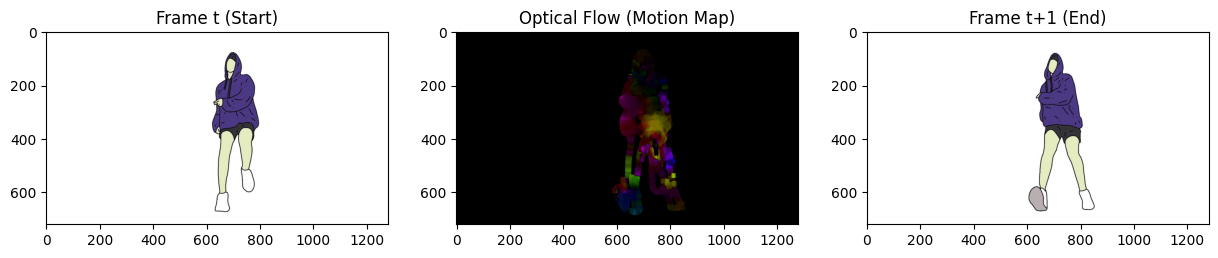

In [4]:
# --- MAIN EXECUTION ---
# 1. Setup Directories
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2. Find all "Frame 0" and "Frame 2" pairs
# We only need the Start and End frames to estimate the motion between them.
triplet_paths = []

for root, dirs, files in os.walk(INPUT_DIR):
    for file in files:
        if file.endswith('_0.png'):
            # Found a start frame! Let's find its matching end frame (_2.png)
            start_path = os.path.join(root, file)
            end_path = start_path.replace('_0.png', '_2.png')
            
            if os.path.exists(end_path):
                triplet_paths.append((start_path, end_path))

print(f"✅ Found {len(triplet_paths)} pairs for motion estimation.")

# 3. Process Flow
for start_p, end_p in tqdm(triplet_paths):
    prev_img = cv2.imread(start_p)
    next_img = cv2.imread(end_p)
    
    if prev_img is None or next_img is None: continue

    # Compute Flow
    flow_data = compute_optical_flow(prev_img, next_img)
    
    # Save the raw data (We save as .npy because images can't store negative numbers!)
    # We maintain the folder structure
    rel_path = os.path.relpath(start_p, INPUT_DIR)
    save_path = os.path.join(OUTPUT_DIR, rel_path.replace('.png', '.npy'))
    
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    np.save(save_path, flow_data)

# --- VISUALIZATION ---
print("Computing finished. Visualizing a random sample:")

# Load the last processed pair
sample_flow = flow_data # Use the last one calculated
sample_vis = visualize_flow(sample_flow)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(cv2.cvtColor(prev_img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Frame t (Start)")
ax[1].imshow(sample_vis)
ax[1].set_title("Optical Flow (Motion Map)")
ax[2].imshow(cv2.cvtColor(next_img, cv2.COLOR_BGR2RGB))
ax[2].set_title("Frame t+1 (End)")
plt.show()